In [1]:
# Tải tập dữ liệu Ames
import pandas as pd
Ames = pd.read_csv('Ames.csv')
# Kiểm tra kích thước tập dữ liệu
print(Ames.shape)
rows, columns = Ames.shape
print(f"Tập dữ liệu bao gồm {rows} bất động sản được mô tả qua {columns} thuộc tính.")


(2579, 85)
Tập dữ liệu bao gồm 2579 bất động sản được mô tả qua 85 thuộc tính.


In [2]:
import pandas as pd
Ames = pd.read_csv('Ames.csv')
# Xác định kiểu dữ liệu của từng thuộc tính
data_types = Ames.dtypes
# Đếm số lượng kiểu dữ liệu
type_counts = data_types.value_counts()
print(type_counts)

object     44
int64      27
float64    14
Name: count, dtype: int64


In [3]:
import pandas as pd
Ames = pd.read_csv('Ames.csv')
# Xác định kiểu dữ liệu của từng thuộc tính
data_types = Ames.dtypes
# Hiển thị một số kiểu dữ liệu từ tập dữ liệu (5 cột đầu và 5 cột cuối)
print(data_types.head())
print(data_types.tail())

PID            int64
GrLivArea      int64
SalePrice      int64
MSSubClass     int64
MSZoning      object
dtype: object
SaleCondition     object
GeoRefNo         float64
Prop_Addr         object
Latitude         float64
Longitude        float64
dtype: object


In [1]:
import pandas as pd
Ames = pd.read_csv('Ames.csv')
# Tính toán số lượng và tỷ lệ phần trăm giá trị bị thiếu của mỗi cột
missing_data = Ames.isnull().sum()
missing_percentage = (missing_data / len(Ames)) * 100
# Gộp số lượng và tỷ lệ phần trăm vào một DataFrame để dễ dàng quan sát
missing_info = pd.DataFrame({'Missing Values': missing_data,
'Percentage': missing_percentage})

# Sắp xếp theo thứ tự giảm dần
missing_info = missing_info.sort_values(by='Percentage', ascending=False)
# Hiển thị các cột có giá trị bị thiếu
print(missing_info[missing_info['Missing Values'] > 0])

              Missing Values  Percentage
PoolQC                  2570   99.651028
MiscFeature             2482   96.238852
Alley                   2411   93.485847
Fence                   2054   79.643273
MasVnrType              1572   60.953858
FireplaceQu             1241   48.119426
LotFrontage              462   17.913920
GarageQual               129    5.001939
GarageYrBlt              129    5.001939
GarageCond               129    5.001939
GarageFinish             129    5.001939
GarageType               127    4.924389
Latitude                  97    3.761148
Longitude                 97    3.761148
BsmtExposure              71    2.753005
BsmtFinType2              70    2.714230
BsmtFinType1              69    2.675456
BsmtQual                  69    2.675456
BsmtCond                  69    2.675456
GeoRefNo                  20    0.775494
Prop_Addr                 20    0.775494
MasVnrArea                14    0.542846
BsmtHalfBath               2    0.077549
BsmtFullBath    

In [3]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
Ames = pd.read_csv('Ames.csv')
msno.matrix(Ames, sparkline=False, fontsize=20)
plt.show()

ModuleNotFoundError: No module named 'missingno'

In [5]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
Ames = pd.read_csv('Ames.csv')
# Tính toán số lượng và tỷ lệ dữ liệu bị thiếu
missing_data = Ames.isnull().sum()
missing_percentage = (missing_data / len(Ames)) * 100
# Kết hợp thành DataFrame
missing_info = pd.DataFrame({'Missing Values': missing_data,
'Percentage': missing_percentage})

# Sắp xếp theo số lượng giá trị bị thiếu
sorted_df = Ames[missing_info.sort_values(by='Percentage', ascending=False).index]
# Chọn 15 cột có nhiều dữ liệu bị thiếu nhất
top_15_missing = sorted_df.iloc[:, :15]
# Trực quan hóa bằng missingno
msno.bar(top_15_missing)
plt.show()

NameError: name 'msno' is not defined

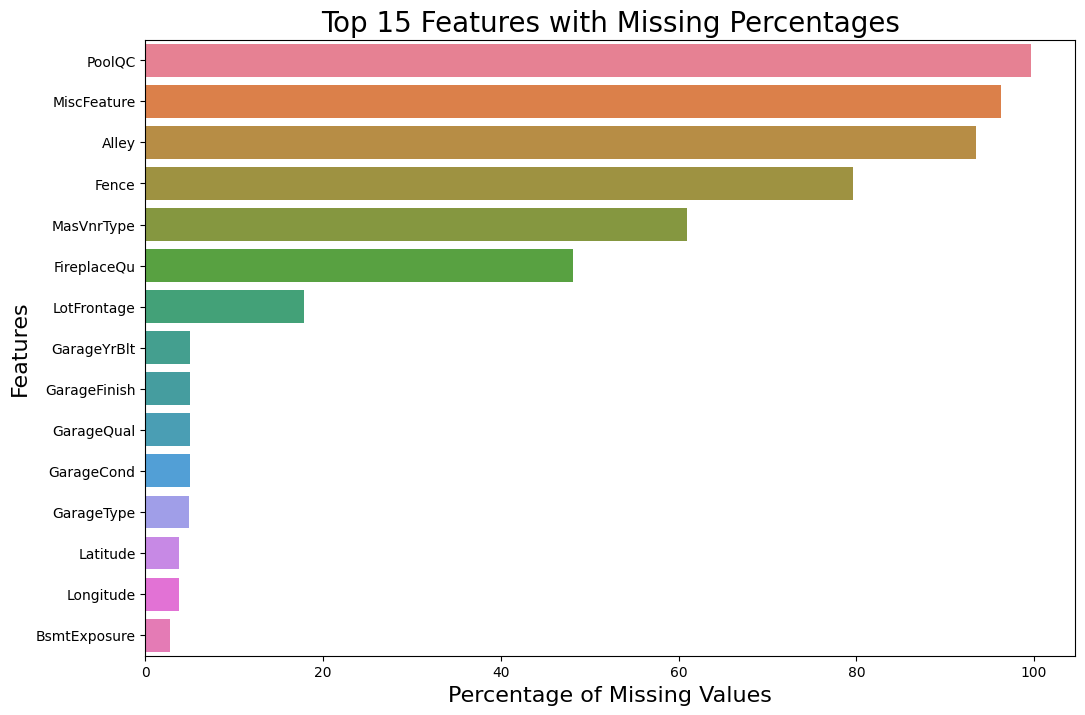

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
Ames = pd.read_csv('Ames.csv')
# Tính toán số lượng và tỷ lệ dữ liệu bị thiếu
missing_data = Ames.isnull().sum()
missing_percentage = (missing_data / len(Ames)) * 100
# Kết hợp thành DataFrame
missing_info = pd.DataFrame({'Missing Values': missing_data,
'Percentage': missing_percentage})

# Lọc ra 15 cột có tỷ lệ giá trị bị thiếu cao nhất
top_15_missing_info = missing_info.nlargest(15, 'Percentage')
# Tạo biểu đồ ngang bằng seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x='Percentage', y=top_15_missing_info.index, hue=top_15_missing_info.index,

data=top_15_missing_info, orient='h')

plt.title('Top 15 Features with Missing Percentages', fontsize=20)
plt.xlabel('Percentage of Missing Values', fontsize=16)
plt.ylabel('Features', fontsize=16)
plt.show()